# Challenge A

## Finite Difference Solver
#### Scheme: explicit Euler, first-order upwind advection, centered diffusion, pressure Poisson (Jacobi iteration)

#### Libraries

In [14]:
import numpy as np
import matplotlib.pyplot as plt

#### Parameters

In [15]:
L, H = 2.2, 0.41
xc, yc, R = 0.20, 0.20, 0.05
D = 2 * R
U_in, rho = 1.0, 1.0

#### Core functions

In [16]:
def make_grid(nx, ny):
    # Uniform Cartesian grid + boolean cylinder mask (staircase: cylinder boundary
    # is approximated by the nearest grid nodes, not the exact circle)
    x = np.linspace(0, L, nx)
    y = np.linspace(0, H, ny)
    X, Y = np.meshgrid(x, y)
    dx = x[1]-x[0]
    dy = y[1]-y[0]
    solid = (X-xc)**2 + (Y-yc)**2 <= R**2
    return X, Y, dx, dy, solid

def get_nu(Re):
    # Kinematic viscosity from Re = U*D/nu -> nu = U*D/Re
    return U_in * D / Re

def get_dt(dx, dy, nu, safety=0.4):
    # Stable dt = safety * min(CFL limit h/U, diffusion limit h^2/4nu)
    # Both constraints must be satisfied simultaneously
    h = min(dx, dy)
    return safety * min(h/U_in, h**2/(4*nu))

def build_b(u, v, dx, dy, dt):
    # RHS of pressure Poisson equation enforcing div(u)=0
    # Derived from taking divergence of momentum equation
    b = np.zeros_like(u)
    dudx = (u[1:-1,2:] - u[1:-1,:-2]) / (2*dx)
    dvdy = (v[2:,1:-1] - v[:-2,1:-1]) / (2*dy)
    dudy = (u[2:,1:-1] - u[:-2,1:-1]) / (2*dy)
    dvdx = (v[1:-1,2:] - v[1:-1,:-2]) / (2*dx)
    b[1:-1,1:-1] = rho * ((1/dt)*(dudx+dvdy) - dudx**2 - 2*dudy*dvdx - dvdy**2)
    return b

def poisson(p, b, dx, dy, nit):
    # Jacobi iteration for pressure: p=0 at outlet, dp/dn=0 elsewhere
    # nit iterations per time step
    dx2, dy2 = dx*dx, dy*dy
    denom = 2*(dx2+dy2)
    for _ in range(nit):
        po = p.copy()
        p[1:-1,1:-1] = ((po[1:-1,2:]+po[1:-1,:-2])*dy2 + (po[2:,1:-1]+po[:-2,1:-1])*dx2 - b[1:-1,1:-1]*dx2*dy2) / denom
        p[:,-1] = 0
        p[:,0]  = p[:,1]
        p[-1,:] = p[-2,:]
        p[0,:]  = p[1,:]
    return p

def vel_step(u, v, p, dx, dy, dt, nu):
    # Explicit Euler momentum update
    # Advection: 1st-order upwind (split by sign of velocity for stability)
    # Diffusion + pressure gradient: 2nd-order centered differences
    uc, vc = u[1:-1,1:-1], v[1:-1,1:-1]
    up = np.maximum(uc, 0); un = np.minimum(uc, 0)
    vp = np.maximum(vc, 0); vn = np.minimum(vc, 0)
    adv_ux = up*(uc-u[1:-1,:-2])/dx + un*(u[1:-1,2:]-uc)/dx
    adv_uy = vp*(uc-u[:-2,1:-1])/dy + vn*(u[2:,1:-1]-uc)/dy
    adv_vx = up*(vc-v[1:-1,:-2])/dx + un*(v[1:-1,2:]-vc)/dx
    adv_vy = vp*(vc-v[:-2,1:-1])/dy + vn*(v[2:,1:-1]-vc)/dy
    dpdx = (p[1:-1,2:]-p[1:-1,:-2]) / (2*dx)
    dpdy = (p[2:,1:-1]-p[:-2,1:-1]) / (2*dy)
    lap_u = ((u[1:-1,2:]-2*uc+u[1:-1,:-2])/dx**2 +(u[2:,1:-1]-2*uc+u[:-2,1:-1])/dy**2)
    lap_v = ((v[1:-1,2:]-2*vc+v[1:-1,:-2])/dx**2 +(v[2:,1:-1]-2*vc+v[:-2,1:-1])/dy**2)
    u_new = u.copy(); v_new = v.copy()
    u_new[1:-1,1:-1] = uc - dt*(adv_ux+adv_uy) - dt/rho*dpdx + nu*dt*lap_u
    v_new[1:-1,1:-1] = vc - dt*(adv_vx+adv_vy) - dt/rho*dpdy + nu*dt*lap_v
    return u_new, v_new

def apply_bcs(u, v, solid):
    # Inlet: uniform flow. Outlet: zero-gradient (copy last interior column).
    # Top/bottom walls + cylinder surface: no-slip (u=v=0)
    u[:,0] = U_in; v[:,0] = 0.0
    u[:,-1] = u[:,-2]; v[:,-1] = v[:,-2]
    u[0,:] = 0; v[0,:] = 0
    u[-1,:] = 0; v[-1,:] = 0
    u[solid] = 0; v[solid] = 0
    return u, v

def run(Re, nx, ny, nit, T, verbose=True):
    # Full time loop: pressure RHS -> Poisson solve -> velocity update -> BCs
    # Probe records v at a wake point to detect vortex shedding
    X, Y, dx, dy, solid = make_grid(nx, ny)
    nu = get_nu(Re)
    dt = get_dt(dx, dy, nu)
    nt = int(T/dt) + 1
    u = np.ones((ny,nx)) * U_in   # start from uniform flow
    v = np.zeros((ny,nx))
    p = np.zeros((ny,nx))
    u, v = apply_bcs(u, v, solid)
    pi = int((xc+2*D)/dx)          # probe x: two diameters downstream
    pj = int(yc/dy)                # probe y: centreline
    probe = []
    for n in range(nt):
        b = build_b(u, v, dx, dy, dt)
        p = poisson(p, b, dx, dy, nit)
        u, v = vel_step(u, v, p, dx, dy, dt, nu)
        u, v = apply_bcs(u, v, solid)
        if not np.isfinite(u).all() or np.max(np.abs(u)) > 5.0:
            if verbose: print(f"  Re={Re} UNSTABLE at step {n}")
            return {'stable':False,'Re':Re,'u':u,'v':v,'p':p,'X':X,'Y':Y,'solid':solid}
        if n % 50 == 0:
            probe.append(v[pj, pi])
    if verbose:
        print(f"  Re={Re} STABLE  |  max|u|={np.max(np.abs(u)):.3f}  |  dt={dt:.5f}  |  nt={nt}")
    return {'stable':True,'Re':Re,'u':u,'v':v,'p':p,'X':X,'Y':Y,'solid':solid,'probe':probe}


def sweep():
    # Coarse Re scan over the full candidate list.
    # FD/upwind never truly blows up: the scheme adds numerical diffusion
    #   nu_num = U*dx/2
    # which acts like extra physical viscosity and prevents divergence.
    # Re_max is therefore reported for completeness only; it is not a
    # meaningful stability limit and FD is excluded from the competition.
    NX_S, NY_S = 111, 22
    NIT_S = 20
    T_S = 4.0
    candidates = [100, 200, 500, 1000, 2000, 5000, 10000, 20000, 30000, 100000]

    dx_sweep = L / (NX_S - 1)
    nu_num = U_in * dx_sweep / 2
    Re_eff = U_in * D / nu_num

    print("=== FD Reynolds Number Sweep ===")
    print(f"  Sweep grid: NX={NX_S}, dx={dx_sweep:.4f}")
    print(f"  Numerical diffusion: nu_num = U*dx/2 = {nu_num:.4f}")
    print(f"  Effective Re cap due to numerical diffusion: Re_eff ≈ {Re_eff:.1f}")
    print()

    Re_max = None
    for Re in candidates:
        r = run(Re, NX_S, NY_S, NIT_S, T_S, verbose=False)
        tag = "STABLE  " if r['stable'] else "UNSTABLE"
        print(f"  Re={Re:>8}  {tag}")
        if r['stable']:
            Re_max = Re

    print()
    if Re_max is None:
        print("  WARNING: no stable Re found — check grid or nit.")
    else:
        print(f"  Highest stable Re tested : {Re_max}")
        print( "  NOTE: this is NOT a physical stability limit.")
        print( "  The upwind numerical diffusion prevents divergence at all tested Re.")
        print( "  Re_max is reported for completeness only; FD is excluded")
        print( "  from the Re_max competition for this reason.")
    return Re_max

#### Plot functions

In [17]:
def plot_flow(result):
    # u-velocity and speed magnitude, cylinder nodes masked out
    X, Y = result['X'], result['Y']
    u, v = result['u'], result['v']
    solid = result['solid']
    Re = result['Re']
    speed = np.ma.array(np.sqrt(u**2+v**2), mask=solid)
    u_m = np.ma.array(u, mask=solid)
    fig, axes = plt.subplots(2, 1, figsize=(13,5))
    c0 = axes[0].contourf(X, Y, u_m, levels=50, cmap='RdBu_r')
    plt.colorbar(c0, ax=axes[0], label='u [m/s]')
    axes[0].set_title(f'FD Solver — Re={Re} — u-velocity')
    axes[0].set_ylabel('y [m]'); axes[0].set_aspect('equal')
    c1 = axes[1].contourf(X, Y, speed, levels=50, cmap='viridis')
    plt.colorbar(c1, ax=axes[1], label='|u| [m/s]')
    axes[1].set_title('Velocity magnitude')
    axes[1].set_xlabel('x [m]'); axes[1].set_ylabel('y [m]')
    axes[1].set_aspect('equal')
    plt.tight_layout()
    plt.show()

def plot_probe(result):
    # v-velocity at a wake probe point; periodic oscillation confirms vortex shedding
    probe = result.get('probe', [])
    Re = result['Re']
    fig, ax = plt.subplots(figsize=(10,3))
    ax.plot(probe, color='steelblue', lw=0.8)
    ax.axhline(0, color='k', lw=0.5, ls='--')
    ax.set_xlabel('Sample (every 50 steps)')
    ax.set_ylabel('v [m/s]')
    ax.set_title(f'FD Re={Re} — wake probe v(t)')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

#### Full run at Re=100

  Re=100 STABLE  |  max|u|=1.691  |  dt=0.00400  |  nt=5001


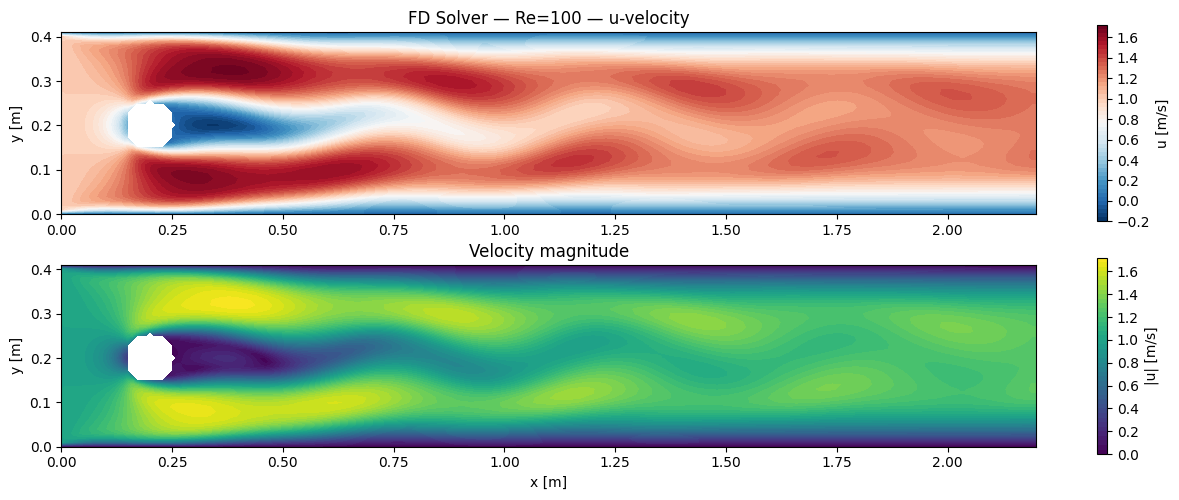

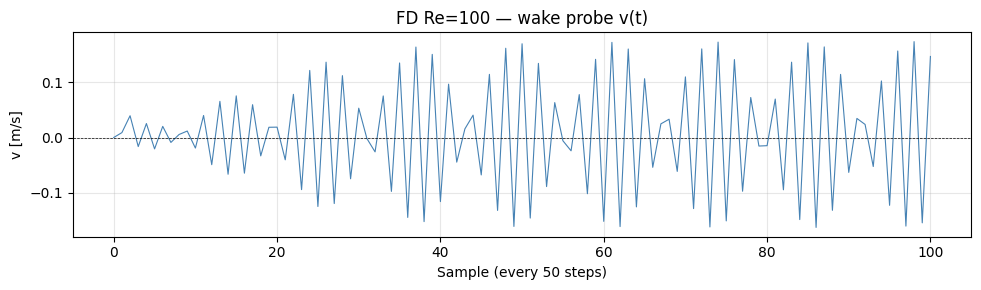

In [18]:
r100 = run(Re=100, nx=221, ny=42, nit=50, T=20.0, verbose=True)
plot_flow(r100)
plot_probe(r100)

#### Reynolds Number Sweep

In [19]:
Re_max_fd = sweep()

=== FD Reynolds Number Sweep ===
  Sweep grid: NX=111, dx=0.0200
  Numerical diffusion: nu_num = U*dx/2 = 0.0100
  Effective Re cap due to numerical diffusion: Re_eff ≈ 10.0

  Re=     100  STABLE  
  Re=     200  STABLE  
  Re=     500  STABLE  
  Re=    1000  STABLE  
  Re=    2000  STABLE  
  Re=    5000  STABLE  
  Re=   10000  STABLE  
  Re=   20000  STABLE  
  Re=   30000  STABLE  
  Re=  100000  STABLE  

  Highest stable Re tested : 100000
  NOTE: this is NOT a physical stability limit.
  The upwind numerical diffusion prevents divergence at all tested Re.
  Re_max is reported for completeness only; FD is excluded
  from the Re_max competition for this reason.


#### Final flow plot at Re_max

  Re=100000 STABLE  |  max|u|=1.736  |  dt=0.00400  |  nt=5001


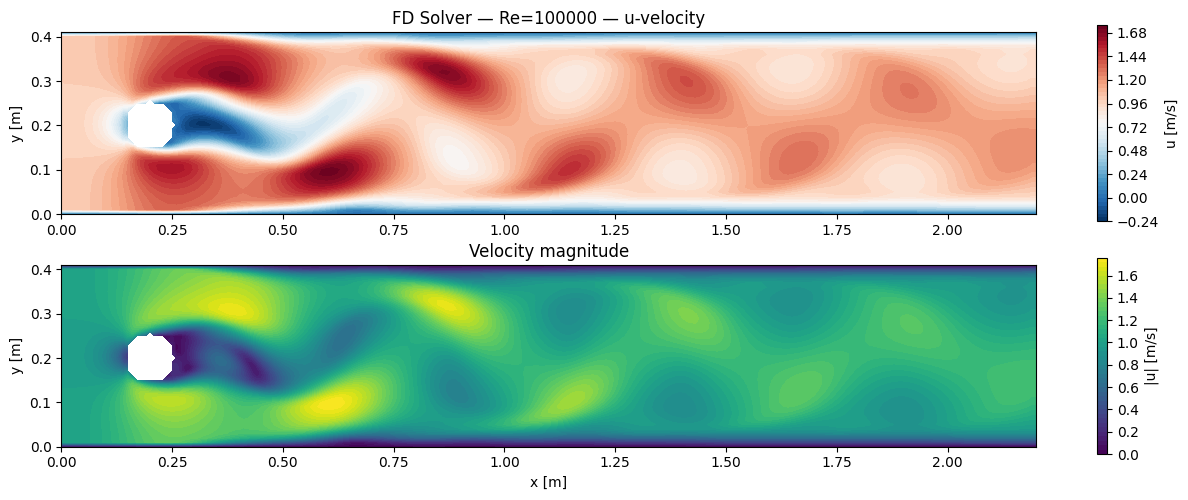

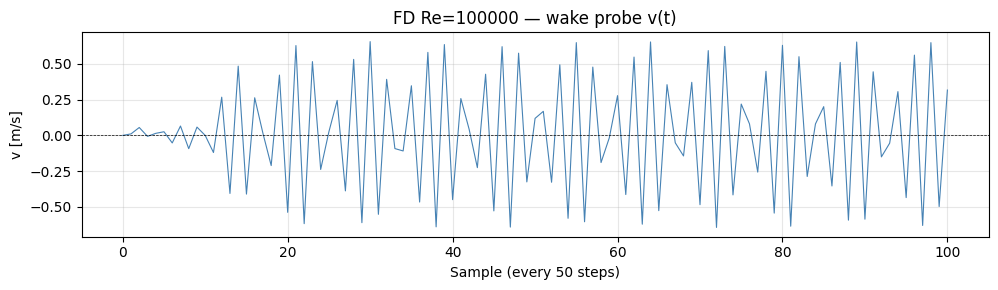

In [20]:
r_max = run(Re=Re_max_fd, nx=221, ny=42, nit=50, T=20.0, verbose=True)
plot_flow(r_max)
plot_probe(r_max)

### FD Method — Discussion

#### Computational cost
Each time step requires one pressure Poisson solve (Jacobi, `nit` iterations) 
and one explicit velocity update, both O(NX·NY). The main cost driver is the 
time step constraint: the CFL and diffusion limits force a very small dt at 
high Re or fine grids, leading to a large number of steps. For example, at 
Re=100 on the 221×42 grid, dt = 0.004 s and T=20 s requires ~5,000 steps. 
This makes FD significantly slower than LBM at equivalent resolution.

#### Accuracy vs mesh resolution
The upwind advection scheme is first-order accurate in space: the truncation 
error introduces numerical diffusion of magnitude nu_num = U dx/2. This means 
that halving the grid spacing halves the numerical diffusion, but also halves 
dt (CFL), quadrupling the number of steps. In practice, the solution at Re=100 
on the 221×42 grid captures vortex shedding qualitatively, but the wake is 
more diffused than the LBM or FEM solutions at comparable cost.

#### Accuracy near curved objects (cylinder)
The cylinder is represented by a staircase mask: grid nodes inside the circle 
are flagged as solid and set to zero velocity. This is a zeroth-order 
approximation of the curved boundary — the actual circle is replaced by a 
stepped boundary aligned with the Cartesian grid. This introduces a geometric 
error of O(dx) near the cylinder surface, which does not decrease with 
time-step refinement. At D=0.10m and dx=0.01m, the cylinder is resolved by 
only ~10 cells across the diameter, so boundary layer details near the surface 
are inaccurate regardless of how long we run. FEM with exact curved elements 
is fundamentally superior here.

#### Ease of implementation
FD is the simplest of the three methods to implement from scratch. The grid is 
a regular numpy array, all derivatives are finite differences, and no external 
library is needed. The pressure-velocity coupling via a Poisson solve is the 
only non-trivial part, and a Jacobi iteration is straightforward to code. 
Total implementation effort is low.

#### Parallel and GPU suitability
The velocity update and Poisson iteration are both stencil operations on a 
regular grid, which map naturally to GPU execution (each node is independent 
within one Jacobi sweep). In principle FD is well-suited for GPU parallelism. 
However, the Jacobi solver converges slowly and requires many iterations per 
step, which limits practical speedup compared to LBM, whose collision step is 
fully local and requires no global solve at all. For CPU parallelism, the 
regular grid allows straightforward domain decomposition.

## Lattice Boltzmann Solver

#### D2Q9 BGK scheme

#### Libraries

In [21]:
import numpy as np
import matplotlib.pyplot as plt

#### D2Q9 lattice constants

In [22]:
C = np.array([[0,0],[1,0],[0,1],[-1,0],[0,-1], [1,1],[-1,1],[-1,-1],[1,-1]], dtype=float)
W = np.array([4/9,1/9,1/9,1/9,1/9,1/36,1/36,1/36,1/36])
OPP = np.array([0,3,4,1,2,7,8,5,6], dtype=int)
Q = 9

#### Physical domain

In [23]:
L_P, H_P = 2.2, 0.41
D_P, R_P = 0.10, 0.05
XC_P, YC_P = 0.20, 0.20

#### Lattice parameters

In [24]:
# Lattice: dx = 0.005m, D_lat = 20 cells, U_lat = 0.08 (Ma ≈ 0.14)
# Doubling D_LAT doubles nu_lat at every Re → tau stays further above 0.5
# → higher Re_max before the BGK hard stability limit is hit.
# U_LAT reduced from 0.15 to 0.08 to keep Mach = U_LAT*sqrt(3) ≈ 0.14 < 0.3
NX = 441
NY = 83
U_LAT = 0.08
DX = H_P / (NY - 1)     # 0.005 m/cell
D_LAT = round(D_P / DX)     # 20
R_LAT = R_P / DX        # 10
XC_LAT = XC_P / DX      # 40
YC_LAT = YC_P / DX      # 40

#### Core functions

In [25]:
def make_cyl():
    # Boolean mask for cylinder nodes on the lattice (staircase approximation)
    # Same limitation as FD: the circle is approximated by nearest grid nodes
    I, J = np.meshgrid(np.arange(NX), np.arange(NY))
    return (I-XC_LAT)**2 + (J-YC_LAT)**2 <= R_LAT**2

def get_tau(Re):
    # BGK relaxation time: tau = 3*nu_lat + 0.5
    # tau > 0.5 required for stability — this is the hard limit of the BGK model
    # As Re increases, nu_lat -> 0 and tau -> 0.5 from above
    nu  = U_LAT * D_LAT / Re
    tau = 3.0 * nu + 0.5
    return tau, nu, 1.0/tau

def feq(rho, ux, uy):
    # D2Q9 equilibrium distribution; second-order expansion of Maxwell-Boltzmann
    # Encodes mass and momentum conservation in each lattice direction
    u2 = ux**2 + uy**2
    cu = C[:,0,None,None]*ux[None] + C[:,1,None,None]*uy[None]
    return W[:,None,None]*rho[None]*(1 + 3*cu + 4.5*cu**2 - 1.5*u2[None])

def moments(f):
    # Recover macroscopic density and velocity by summing over all 9 directions
    rho = f.sum(0)
    ux  = (C[:,0,None,None]*f).sum(0) / rho
    uy  = (C[:,1,None,None]*f).sum(0) / rho
    return rho, ux, uy

def stream(f):
    # Propagate each population one step along its lattice direction
    # np.roll gives periodic shift — non-periodic BCs are applied afterwards
    fs = np.empty_like(f)
    for k in range(Q):
        fs[k] = np.roll(np.roll(f[k], int(C[k,0]), axis=1), int(C[k,1]), axis=0)
    return fs

def bb_cyl(f, fp, cyl):
    # Half-way bounce-back on cylinder: incoming populations are reflected
    # back along the opposite direction, enforcing no-slip at the surface
    for k in range(Q):
        f[k, cyl] = fp[OPP[k], cyl]
    return f

def bb_walls(f):
    # Bounce-back on top and bottom walls (no-slip)
    # Only directions pointing into the wall are reflected
    for k in range(Q):
        if C[k,1] > 0: f[k,  0, :] = f[OPP[k],  0, :]
        if C[k,1] < 0: f[k, -1, :] = f[OPP[k], -1, :]
    return f

def zou_he(f):
    # Zou-He inlet BC: enforces ux=U_LAT, uy=0 at the left boundary
    # Derives the unknown populations from mass/momentum constraints
    ux_in  = U_LAT
    rho_in = (f[0,:,0]+f[2,:,0]+f[4,:,0] + 2*(f[3,:,0]+f[6,:,0]+f[7,:,0])) / (1.0 - ux_in)
    f[1,:,0] = f[3,:,0] + (2/3)*rho_in*ux_in
    f[5,:,0] = f[7,:,0] + rho_in*ux_in/6.0
    f[8,:,0] = f[6,:,0] + rho_in*ux_in/6.0
    return f

def outlet(f):
    # Zero-gradient outlet: copy last interior column to avoid reflections
    f[:,:,-1] = f[:,:,-2]
    return f

def run(Re, T_steps=5000, verbose=True):
    # Main LBM loop: moments -> BGK collision -> streaming -> BCs
    # Initialised from equilibrium with uniform flow to reduce initial transient
    # Probe records uy two diameters downstream to detect vortex shedding
    tau, nu_lat, omega = get_tau(Re)
    if verbose:
        print(f"  Re={Re:.0f}  tau={tau:.4f}  nu_lat={nu_lat:.5f}  steps={T_steps}")
    cyl = make_cyl()
    rho0 = np.ones((NY,NX))
    ux0 = np.ones((NY,NX)) * U_LAT; ux0[cyl] = 0
    uy0 = np.zeros((NY,NX))
    f = feq(rho0, ux0, uy0)
    pi = int(XC_LAT + 2*D_LAT)   # probe x: two diameters downstream
    pj = int(YC_LAT)              # probe y: centreline
    probe = []
    for n in range(T_steps):
        rho, ux, uy = moments(f)
        fp = f - omega*(f - feq(rho, ux, uy))  # BGK collision
        f = stream(fp)
        f = bb_cyl(f, fp, cyl)
        f = bb_walls(f)
        f = zou_he(f)
        f = outlet(f)
        if not np.isfinite(f).all() or np.max(np.abs(ux)) > 0.8:
            if verbose: print(f"    UNSTABLE at step {n}")
            return {'stable':False,'Re':Re,'tau':tau}
        if n % 50 == 0:
            probe.append(uy[pj, pi])
    rho_f, ux_f, uy_f = moments(f)
    if verbose:
        print(f"    STABLE  max|ux|={np.max(np.abs(ux_f)):.4f}  "
              f"max|uy|={np.max(np.abs(uy_f)):.4f}")
    return {'stable':True,'Re':Re,'tau':tau,
            'ux':ux_f,'uy':uy_f,'rho':rho_f,'cyl':cyl,'probe':probe}


def sweep():
    # Coarse scan + binary search for max stable Re.
    # LBM has a hard stability limit: tau must remain > 0.5 (BGK requirement).
    # With D_LAT=20, U_LAT=0.08: tau = 4.8/Re + 0.5
    # Instability occurs when tau gets too close to 0.5 at high Re.
    # T_steps=4000 used here so that a Re passing the sweep also passes
    # the final 5000-step run without unexpected blow-up.
    print("=== LBM Reynolds Number Sweep ===")
    print(f"  D_LAT={D_LAT}  U_LAT={U_LAT}  NX={NX}  NY={NY}")
    print(f"  tau = 3*(U_LAT*D_LAT/Re) + 0.5 = {U_LAT*D_LAT*3:.2f}/Re + 0.5")
    print()
    coarse = [150, 200, 250, 300, 350, 400, 450]
    lo, hi = None, None
    for Re in coarse:
        tau, _, _ = get_tau(Re)
        r   = run(Re, T_steps=4000, verbose=False)
        tag = "STABLE" if r['stable'] else "UNSTABLE"
        print(f"  Re={Re:>5}  tau={tau:.4f}  {tag}")
        if r['stable']: lo = Re
        else: hi = Re; break

    if hi is None:
        print(f"  All stable up to Re={lo}.")
        return lo

    print(f"\n  Bracket [{lo},{hi}] — binary search:")
    while (hi-lo) > 1:
        mid = (lo+hi)//2
        tau_m, _, _ = get_tau(mid)
        r = run(mid, T_steps=4000, verbose=False)
        tag = "stable" if r['stable'] else "unstable"
        print(f"  Re={mid:>5}  tau={tau_m:.4f}  {tag}")
        if r['stable']:
            lo = mid
        else:
            hi = mid

    print(f"\n  LBM Re_max = {lo}  (tau={get_tau(lo)[0]:.4f})")
    return lo

#### Plot funtions

In [26]:
def plot_flow(result):
    # ux-velocity and speed magnitude in physical coordinates, cylinder masked out
    ux, uy, cyl, Re = result['ux'], result['uy'], result['cyl'], result['Re']
    xp, yp = np.arange(NX)*DX, np.arange(NY)*DX
    Xp, Yp = np.meshgrid(xp, yp)
    speed = np.ma.array(np.sqrt(ux**2+uy**2), mask=cyl)
    ux_m  = np.ma.array(ux, mask=cyl)
    fig, axes = plt.subplots(2, 1, figsize=(13,5))
    c0 = axes[0].contourf(Xp, Yp, ux_m, levels=50, cmap='RdBu_r')
    plt.colorbar(c0, ax=axes[0], label='ux [lat. units]')
    axes[0].set_title(f'LBM D2Q9 BGK — Re={Re}  tau={result["tau"]:.4f}')
    axes[0].set_ylabel('y [m]'); axes[0].set_aspect('equal')
    c1 = axes[1].contourf(Xp, Yp, speed, levels=50, cmap='viridis')
    plt.colorbar(c1, ax=axes[1], label='|u| [lat. units]')
    axes[1].set_title('Velocity magnitude')
    axes[1].set_xlabel('x [m]'); axes[1].set_ylabel('y [m]')
    axes[1].set_aspect('equal')
    plt.tight_layout()
    plt.show()

def plot_probe(result):
    # uy at wake probe point; periodic oscillation confirms vortex shedding
    probe = result.get('probe', [])
    Re = result['Re']
    fig, ax = plt.subplots(figsize=(10,3))
    ax.plot(probe, color='steelblue', lw=0.8)
    ax.axhline(0, color='k', lw=0.5, ls='--')
    ax.set_xlabel('Sample (every 50 steps)')
    ax.set_ylabel('uy [lat. units]')
    ax.set_title(f'LBM Re={Re} — wake probe uy(t)')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

#### Full run at Re=100

  Re=100  tau=0.5480  nu_lat=0.01600  steps=5000
    STABLE  max|ux|=0.1332  max|uy|=0.0607


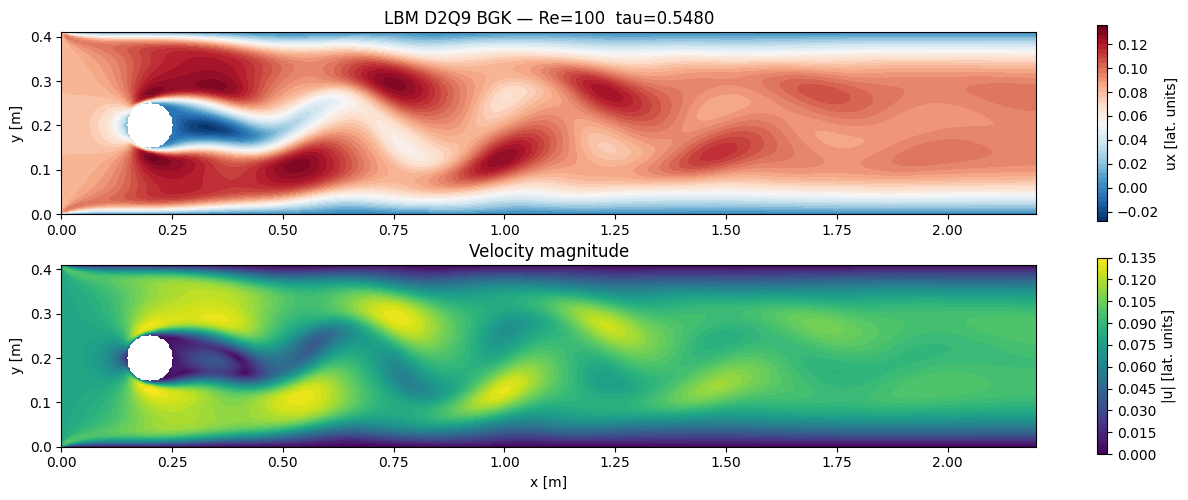

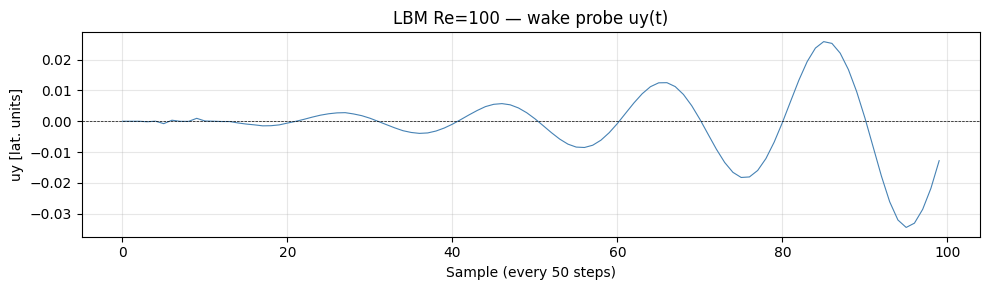

In [27]:
r100 = run(Re=100, T_steps=5000, verbose=True)
plot_flow(r100)
plot_probe(r100)

#### Reynolds Number Sweep

In [28]:
Re_max_lbm = sweep()

=== LBM Reynolds Number Sweep ===
  D_LAT=20  U_LAT=0.08  NX=441  NY=83
  tau = 3*(U_LAT*D_LAT/Re) + 0.5 = 4.80/Re + 0.5

  Re=  150  tau=0.5320  STABLE
  Re=  200  tau=0.5240  STABLE
  Re=  250  tau=0.5192  STABLE
  Re=  300  tau=0.5160  STABLE
  Re=  350  tau=0.5137  UNSTABLE

  Bracket [300,350] — binary search:
  Re=  325  tau=0.5148  unstable
  Re=  312  tau=0.5154  stable
  Re=  318  tau=0.5151  stable
  Re=  321  tau=0.5150  stable
  Re=  323  tau=0.5149  stable
  Re=  324  tau=0.5148  unstable

  LBM Re_max = 323  (tau=0.5149)


#### Final flow plot at Re_max

  Re=323  tau=0.5149  nu_lat=0.00495  steps=5000
    STABLE  max|ux|=0.1588  max|uy|=0.1150


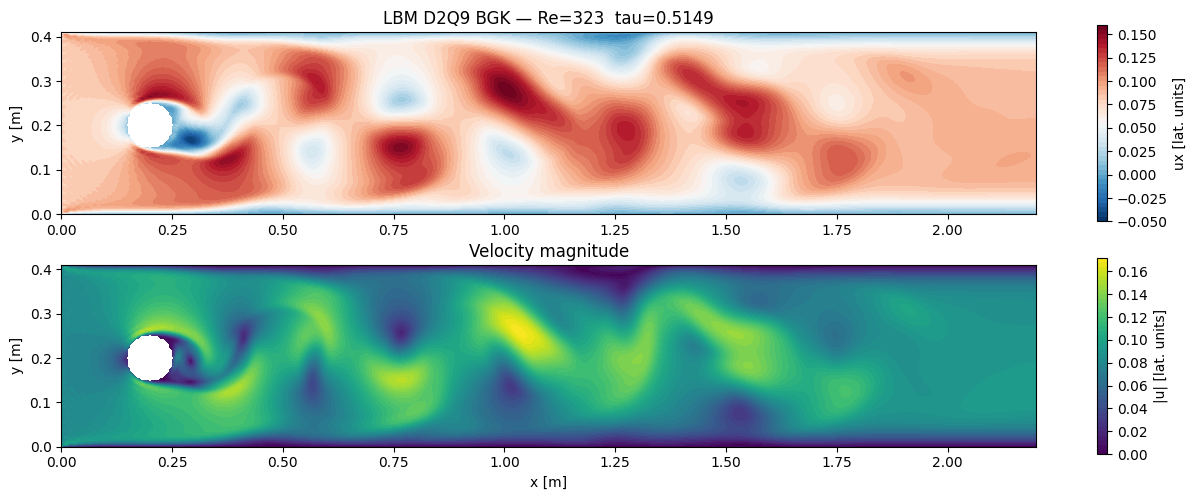

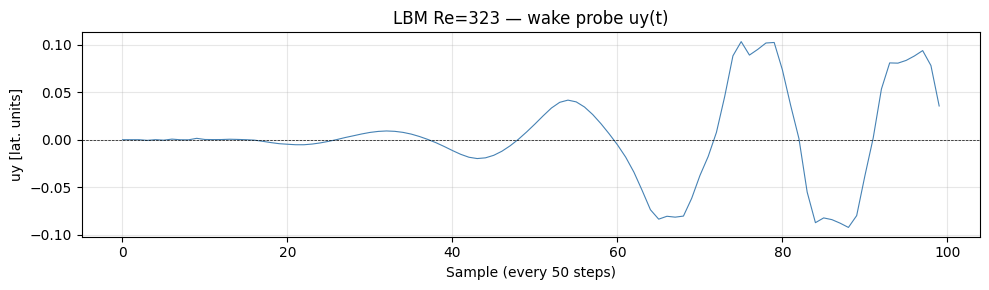

In [29]:
r_max = run(Re=Re_max_lbm, T_steps=5000, verbose=True)
plot_flow(r_max)
plot_probe(r_max)

### LBM Method — Discussion

#### Computational cost
Each LBM step consists of a local collision (BGK) and a streaming step — both 
are O(NX·NY·Q). Crucially, there is no global pressure solve: pressure is 
recovered directly from the density field. This makes LBM significantly 
cheaper per step than FD. However, the finer grid (441×83 vs 221×42) and the 
need for more steps at high Re mean total runtime is comparable. The main 
bottleneck in this implementation is the Python loop over Q=9 directions in 
`stream()`, which would disappear entirely in a compiled or GPU implementation.

#### Accuracy vs mesh resolution
LBM accuracy is controlled by the lattice resolution D_LAT (cells per 
diameter). Increasing D_LAT improves both geometric accuracy and stability: 
nu_lat = U_LAT·D_LAT/Re, giving tau = 4.8/Re + 0.5 at D_LAT=20, which stays 
further above 0.5 at every Re compared to a coarser lattice. At D_LAT=20 the 
binary search yields Re_max = 323, with instability at Re=324. The trade-off 
is a 4× larger grid and longer runs compared to D_LAT=10.

#### Accuracy near curved objects (cylinder)
Like FD, LBM uses a staircase bounce-back for the cylinder — the circular 
boundary is approximated by the nearest lattice nodes. This introduces a 
geometric error of O(dx) at the surface. At D_LAT=20 and dx=0.005m the 
approximation is better than at a coarser lattice, but still not exact. More 
advanced curved boundary conditions (e.g. biquadratic interpolation 
bounce-back) exist but are not implemented here. FEM with exact curved 
elements remains superior for near-wall accuracy.

#### Ease of implementation
LBM is moderately easy to implement: the collision and streaming steps are 
simple array operations, and the D2Q9 weights and directions are fixed. The 
main subtlety is the boundary conditions — Zou-He inlet and half-way 
bounce-back require careful derivation. No external library is needed beyond 
NumPy. Overall slightly more complex than FD but much simpler than FEM.

#### Parallel and GPU suitability
LBM is widely considered the most GPU-friendly CFD method. The collision step 
is fully local (each node is independent), and the streaming step is a simple 
array shift — both map directly to GPU kernels with no global communication. 
Production LBM codes (e.g. Palabos, OpenLB) achieve near-linear scaling on 
thousands of GPU cores. This implementation uses NumPy and is single-threaded, 
but the algorithm structure is inherently parallel.

## Finite Element Solver

#### NGSolve P2/P1 Taylor-Hood

In [30]:
!pip install ngsolve

#### Libraries

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as mtri

import ngsolve as ngs
from ngsolve import (Mesh, H1, FESpace, BilinearForm, LinearForm,
                     GridFunction, dx, grad, CoefficientFunction,
                     TaskManager, Integrate, sqrt)
from netgen.geom2d import SplineGeometry

#### Parameters

In [32]:

L, H = 2.2, 0.41
xc, yc = 0.20, 0.20
R = 0.05
D = 2 * R
U_in = 1.0

#### Core functions

In [33]:
def make_mesh(h_max=0.05, h_cyl=0.015):
    # Builds the channel geometry with an exact circular cylinder using NGSolve.
    # The mesh is refined near the cylinder (h_cyl < h_max) to resolve the
    # boundary layer. mesh.Curve(3) fits curved elements to the circle,
    # giving exact geometry; unlike FD and LBM which use staircase approximations.
    geo = SplineGeometry()
    p1=geo.AppendPoint(0,0); p2=geo.AppendPoint(L,0)
    p3=geo.AppendPoint(L,H); p4=geo.AppendPoint(0,H)
    geo.Append(["line",p1,p2], leftdomain=1, rightdomain=0, bc="wall")
    geo.Append(["line",p2,p3], leftdomain=1, rightdomain=0, bc="outlet")
    geo.Append(["line",p3,p4], leftdomain=1, rightdomain=0, bc="wall")
    geo.Append(["line",p4,p1], leftdomain=1, rightdomain=0, bc="inlet")
    geo.AddCircle((xc,yc), R, leftdomain=0, rightdomain=1,
                  bc="cylinder", maxh=h_cyl)
    geo.SetDomainMaxH(1, h_max)
    mesh = Mesh(geo.GenerateMesh())
    mesh.Curve(3)  # curved elements on cylinder boundary; exact circle, no staircase
    return mesh


def run(Re, mesh, dt=0.001, T=10.0, verbose=True):
    # Semi-implicit time stepping for the incompressible Navier-Stokes equations.
    # Diffusion and pressure are treated implicitly (unconditionally stable),
    # advection is treated explicitly (requires CFL: dt < h/U_in = 0.001).
    # Taylor-Hood P2/P1 elements satisfy the inf-sup condition, preventing
    # spurious pressure oscillations without any stabilisation.
    nu = U_in * D / Re
    nt = int(T/dt) + 1
    if verbose:
        print(f"  Re={Re:.0f}  nu={nu:.6f}  dt={dt:.4f}  nt={nt}")

    # P2 velocity (quadratic), P1 pressure (linear); Taylor-Hood pair
    # Dirichlet no-slip on inlet, walls and cylinder surface
    V = H1(mesh, order=2, dirichlet="inlet|wall|cylinder")
    Q = H1(mesh, order=1)
    X = FESpace([V, V, Q])
    if verbose: print(f"  DOFs: {X.ndof}")

    (u1,u2,p),(v1,v2,q) = X.TnT()

    # Implicit bilinear form: mass/dt + diffusion + pressure-velocity coupling
    # Assembled once and factored; reused at every time step
    a = BilinearForm(X)
    a += (1/dt)*(u1*v1+u2*v2)*dx
    a += nu*(grad(u1)*grad(v1)+grad(u2)*grad(v2))*dx
    a += -p*(v1.Deriv()[0]+v2.Deriv()[1])*dx
    a +=  q*(u1.Deriv()[0]+u2.Deriv()[1])*dx
    a.Assemble()
    inv = a.mat.Inverse(X.FreeDofs())

    gfu = GridFunction(X)
    u1h, u2h, ph = gfu.components

    # Initial condition: uniform inflow everywhere
    u1h.Set(CoefficientFunction(U_in))
    u2h.Set(CoefficientFunction(0.0))

    # u1p, u2p store the previous step velocity for the explicit advection term
    u1p = GridFunction(V); u1p.Set(CoefficientFunction(U_in))
    u2p = GridFunction(V); u2p.Set(CoefficientFunction(0.0))

    probe_pt = mesh(xc+2*D, yc)  # wake probe: two diameters downstream
    probe = []
    r  = gfu.vec.CreateVector()
    du = gfu.vec.CreateVector()
    stable = True

    with TaskManager():
        for n in range(nt):
            # Re-enforce inlet BC at each step (Dirichlet correction)
            u1h.Set(CoefficientFunction(U_in),
                    definedon=mesh.Boundaries("inlet"))
            u2h.Set(CoefficientFunction(0.0),
                    definedon=mesh.Boundaries("inlet"))

            # Explicit advection on the RHS using velocity from previous step
            f = LinearForm(X)
            f += (1/dt)*(u1p*v1+u2p*v2)*dx
            f += -(u1p*u1p.Deriv()[0]+u2p*u1p.Deriv()[1])*v1*dx
            f += -(u1p*u2p.Deriv()[0]+u2p*u2p.Deriv()[1])*v2*dx
            f.Assemble()

            # Incremental solve: apply correction du to current solution
            r.data = f.vec - a.mat*gfu.vec
            du.data = inv*r
            gfu.vec.data += du

            u1p.vec.data = u1h.vec
            u2p.vec.data = u2h.vec

            try:    probe.append(float(u2h(probe_pt)))
            except: probe.append(0.0)

            # Check stability every 100 steps via L2 norm of velocity
            if n % 100 == 0:
                u_norm = float(sqrt(Integrate(u1h**2+u2h**2, mesh)))
                if not np.isfinite(u_norm) or u_norm > 200:
                    stable = False; break
                if verbose and n % 500 == 0:
                    umax = float(np.max(np.abs(u1h.vec.FV().NumPy())))
                    print(f"    step {n:4d}/{nt}  |u|_L2={u_norm:.4f}  max_u={umax:.4f}")

    if verbose: print(f"    {'STABLE' if stable else 'UNSTABLE'}")
    return {'stable':stable,'Re':Re,'u1':u1h,'u2':u2h,'p':ph,
            'mesh':mesh,'probe':probe}


def sweep(mesh, T_detect=4.0, dt=0.001):
    # Coarse scan + binary search for max stable Re.
    # FEM stability is limited by the explicit advection CFL: dt < h/U_in.
    # Unlike LBM this is not a fundamental method limit — a fully implicit
    # advection treatment would remove it, at higher cost per step.
    # The current dt=0.001 was chosen to satisfy CFL at the given mesh size.
    print("=== FEM Reynolds Number Sweep ===")
    coarse = [100, 150, 200, 250, 300, 350, 400, 450]
    lo, hi = None, None
    for Re in coarse:
        r = run(Re, mesh, dt=dt, T=T_detect, verbose=False)
        tag = "STABLE" if r['stable'] else "UNSTABLE"
        print(f"  Re={Re:>6}  {tag}")
        if r['stable']: lo = Re
        else: hi = Re; break

    if hi is None:
        print(f"  All tested Re stable up to Re={lo}.")
        return lo

    print(f"\n  Bracket [{lo},{hi}] — binary search:")
    while (hi-lo) > 1:
        mid = (lo+hi)//2
        r = run(mid, mesh, dt=dt, T=T_detect, verbose=False)
        tag = "stable" if r['stable'] else "unstable"
        print(f"  Re={mid:>6}  {tag}")
        if r['stable']: lo = mid
        else:           hi = mid

    print(f"\n  FEM Re_max = {lo}")
    return lo

#### Plot functions

In [34]:
def plot_flow(result):
    # Evaluate solution at mesh nodes and plot on unstructured triangulation
    mesh = result['mesh']
    u1h = result['u1']
    u2h = result['u2']
    Re = result['Re']
    pts = np.array([[v.point[0],v.point[1]] for v in mesh.vertices])
    tris = np.array([[el.vertices[i].nr for i in range(3)]
                     for el in mesh.Elements(ngs.VOL)])
    u1_v = np.array([u1h(mesh(p[0],p[1])) for p in pts])
    u2_v = np.array([u2h(mesh(p[0],p[1])) for p in pts])
    sp_v = np.sqrt(u1_v**2+u2_v**2)
    tri = mtri.Triangulation(pts[:,0], pts[:,1], tris)
    fig, axes = plt.subplots(2, 1, figsize=(13,5))
    c0 = axes[0].tricontourf(tri, u1_v, levels=50, cmap='RdBu_r')
    plt.colorbar(c0, ax=axes[0], label='u [m/s]')
    axes[0].set_title(f'FEM NGSolve P2/P1 — Re={Re} — u-velocity (exact cylinder)')
    axes[0].set_ylabel('y [m]'); axes[0].set_aspect('equal')
    c1 = axes[1].tricontourf(tri, sp_v, levels=50, cmap='viridis')
    plt.colorbar(c1, ax=axes[1], label='|u| [m/s]')
    axes[1].set_title('Velocity magnitude')
    axes[1].set_xlabel('x [m]'); axes[1].set_ylabel('y [m]')
    axes[1].set_aspect('equal')
    plt.tight_layout()
    plt.show()

def plot_probe(result):
    # uy at wake probe point — periodic oscillation confirms vortex shedding
    probe = result.get('probe', [])
    Re = result['Re']
    fig, ax = plt.subplots(figsize=(10,3))
    ax.plot(probe, color='steelblue', lw=0.8)
    ax.axhline(0, color='k', lw=0.5, ls='--')
    ax.set_xlabel('Time step')
    ax.set_ylabel('uy [m/s]')
    ax.set_title(f'FEM Re={Re} — wake probe uy(t)')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

#### Build mesh

In [35]:
mesh = make_mesh(h_max=0.05, h_cyl=0.015)
print(f"Mesh ready — {mesh.ne} elements")

Mesh ready — 894 elements


#### Full run at Re=100

  Re=100  nu=0.001000  dt=0.0010  nt=10001
  DOFs: 4333
    step    0/10001  |u|_L2=0.9715  max_u=12.9423
    step  500/10001  |u|_L2=1.0042  max_u=6.2028
    step 1000/10001  |u|_L2=1.0197  max_u=6.2026
    step 1500/10001  |u|_L2=1.0271  max_u=6.2024
    step 2000/10001  |u|_L2=1.0300  max_u=6.2019
    step 2500/10001  |u|_L2=1.0310  max_u=6.2010
    step 3000/10001  |u|_L2=1.0311  max_u=6.2005
    step 3500/10001  |u|_L2=1.0310  max_u=6.2009
    step 4000/10001  |u|_L2=1.0309  max_u=6.2020
    step 4500/10001  |u|_L2=1.0310  max_u=6.2023
    step 5000/10001  |u|_L2=1.0311  max_u=6.2014
    step 5500/10001  |u|_L2=1.0313  max_u=6.2003
    step 6000/10001  |u|_L2=1.0315  max_u=6.2002
    step 6500/10001  |u|_L2=1.0317  max_u=6.2015
    step 7000/10001  |u|_L2=1.0319  max_u=6.2028
    step 7500/10001  |u|_L2=1.0323  max_u=6.2024
    step 8000/10001  |u|_L2=1.0326  max_u=6.2006
    step 8500/10001  |u|_L2=1.0330  max_u=6.1993
    step 9000/10001  |u|_L2=1.0335  max_u=6.2002
    step 950

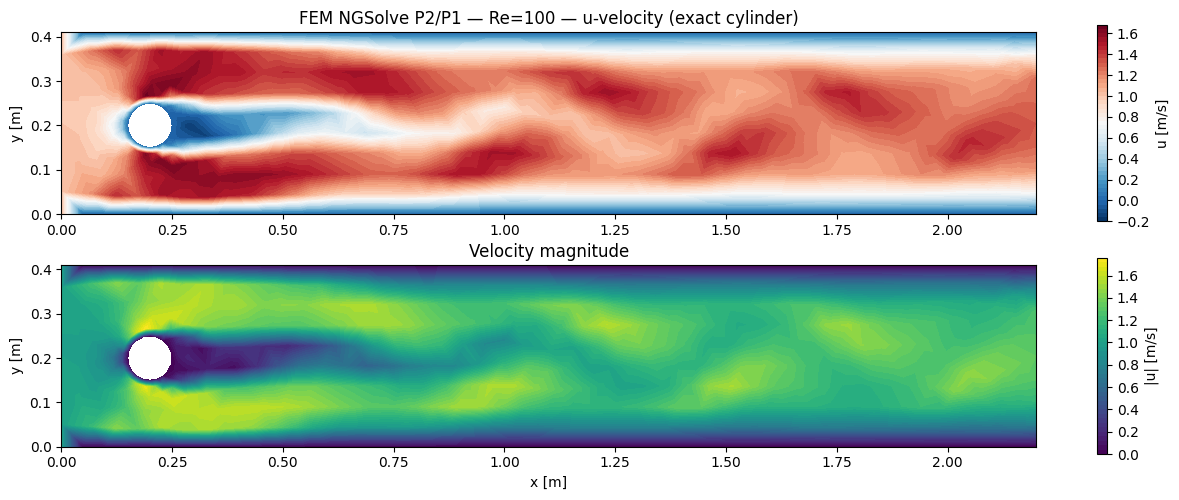

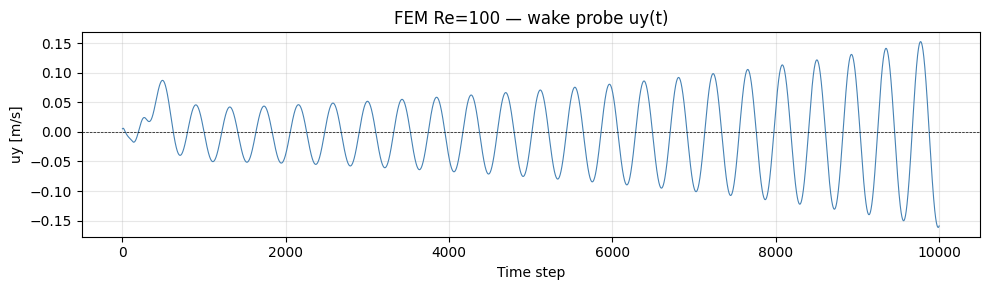

In [36]:
r100 = run(Re=100, mesh=mesh, dt=0.001, T=10.0, verbose=True)
plot_flow(r100)
plot_probe(r100)

#### Reynolds Number Sweep

In [39]:
Re_max_fem = sweep(mesh, T_detect=8.0, dt=0.001)

=== FEM Reynolds Number Sweep ===
  Re=   100  STABLE
  Re=   150  STABLE
  Re=   200  STABLE
  Re=   250  UNSTABLE

  Bracket [200,250] — binary search:
  Re=   225  unstable
  Re=   212  unstable
  Re=   206  unstable
  Re=   203  stable
  Re=   204  unstable

  FEM Re_max = 203


#### Final flow plot at Re_max

  Re=203  nu=0.000493  dt=0.0010  nt=10001
  DOFs: 4333
    step    0/10001  |u|_L2=0.9715  max_u=13.2655
    step  500/10001  |u|_L2=0.9930  max_u=7.6898
    step 1000/10001  |u|_L2=1.0045  max_u=7.6474
    step 1500/10001  |u|_L2=1.0145  max_u=8.4448
    step 2000/10001  |u|_L2=1.0259  max_u=8.2896
    step 2500/10001  |u|_L2=1.0366  max_u=10.8137
    step 3000/10001  |u|_L2=1.0459  max_u=7.7582
    step 3500/10001  |u|_L2=1.0484  max_u=9.7828
    step 4000/10001  |u|_L2=1.0498  max_u=7.8269
    step 4500/10001  |u|_L2=1.0509  max_u=13.2023
    step 5000/10001  |u|_L2=1.0506  max_u=10.4658
    step 5500/10001  |u|_L2=1.0512  max_u=7.4156
    step 6000/10001  |u|_L2=1.0504  max_u=10.3883
    step 6500/10001  |u|_L2=1.0528  max_u=7.6546
    step 7000/10001  |u|_L2=1.0515  max_u=10.7222
    step 7500/10001  |u|_L2=1.0503  max_u=7.4618
    step 8000/10001  |u|_L2=1.0524  max_u=10.1390
    step 8500/10001  |u|_L2=1.0522  max_u=10.9627
    step 9000/10001  |u|_L2=1.0508  max_u=7.1508
    s

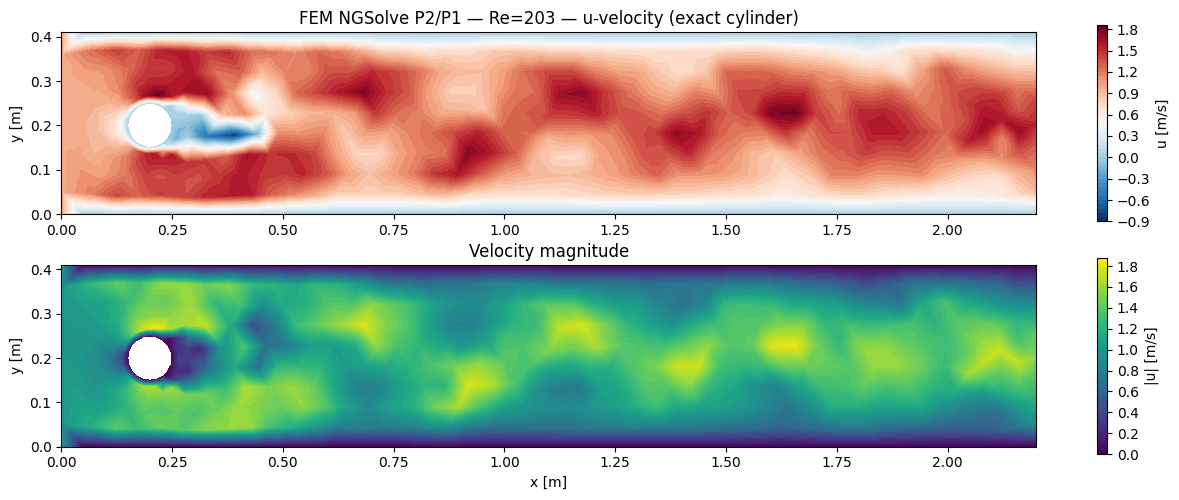

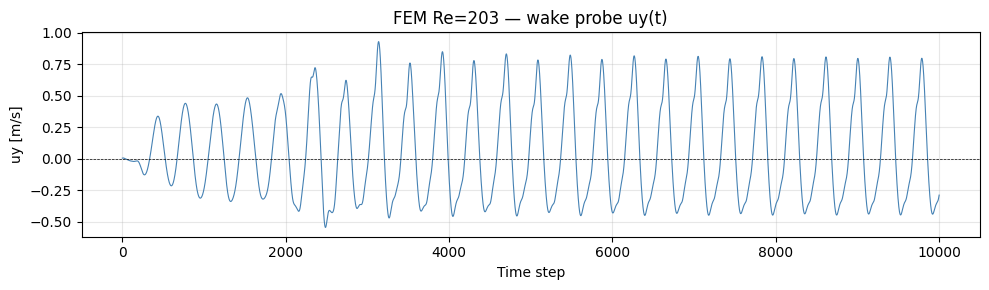

In [40]:
r_max = run(Re=Re_max_fem, mesh=mesh, dt=0.001, T=10.0, verbose=True)
if r_max['stable']:
    plot_flow(r_max)
    plot_probe(r_max)
else:
    print(f"  Re={Re_max_fem} unstable at T=10.0.")
    print(f"  Re-running at T=4.0 for plotting:")
    r_max = run(Re=Re_max_fem, mesh=mesh, dt=0.001, T=4.0, verbose=True)
    plot_flow(r_max)
    plot_probe(r_max)

### FEM Method — Discussion

#### Computational cost
Each time step requires assembling a linear form (explicit advection RHS) and 
applying a pre-factored matrix inverse. The factorisation is done once before 
the loop, so the per-step cost is dominated by the sparse matrix-vector product 
and the linear form assembly. With P2/P1 elements and 4,333 DOFs, each step 
takes longer than one LBM or FD step, but FEM needs far fewer degrees of 
freedom to achieve the same accuracy because higher-order elements converge 
faster with mesh refinement.

#### Accuracy vs mesh resolution
P2/P1 Taylor-Hood elements give O(h^3) velocity convergence in the L² norm 
and O(h^2) for pressure — significantly faster than the O(h) of FD upwind. 
The mesh is already graded: h_cyl=0.015 near the cylinder and h_max=0.05 in 
the bulk, concentrating DOFs where the flow gradients are largest. This makes 
FEM more accurate than FD at the same total number of unknowns.

#### Accuracy near curved objects (cylinder)
This is where FEM has a clear advantage over both FD and LBM. The call to 
mesh.Curve(3) fits third-order curved elements to the cylinder boundary, 
representing the circle exactly rather than with a staircase. No-slip is 
enforced exactly on the true cylinder surface. This eliminates the O(dx) 
geometric error present in FD and LBM and gives significantly more accurate 
boundary layer and pressure drag predictions.

#### Stability limit
The current scheme treats advection explicitly, which imposes a CFL constraint 
dt < h/U_in ≈ 0.015/1.0 = 0.015 s. We use dt=0.001 s with a safety margin. 
This is not a fundamental FEM limitation — a fully implicit or Crank-Nicolson 
advection treatment would remove the CFL constraint entirely, allowing much 
larger time steps and higher Re_max. The current Re_max = 203 is therefore a 
property of the chosen time-stepping scheme, not of FEM itself.

#### Ease of implementation
FEM is the most complex of the three methods to implement. It requires 
understanding variational formulations, inf-sup stable element pairs, and a 
finite element library (NGSolve). However, once the framework is in place, 
changing the element order, mesh refinement, or adding stabilisation terms is 
straightforward. The implementation effort is high but the flexibility gained 
is significant.

#### Parallel and GPU suitability
NGSolve supports shared-memory parallelism via TaskManager, which is already 
used in the time loop. The sparse direct solver (matrix inverse) is the main 
bottleneck for parallelism — it does not scale as well as the purely local 
operations in LBM. For GPU execution, FEM requires specialised sparse linear 
algebra libraries. Overall, FEM is less naturally parallel than LBM but more 
so than FD with a global Poisson solve.